Цель работы: изучение алгоритмов и методов кластеризации на практике.

Вариант: 2

Задание:

Часть 1 — Кластеризация синтетического набора данных методом k‑means:

- Использовать функцию для создания набора данных. 
- Получить с помощью этой функции набор данных.
- Провести стандартизацию данных.
- С помощью метода fit_predict  обучить модель для кластеризации методом Kmeans для
трёх кластеров. Выполнить предсказание. Получить метки кластеров.
- Провести визуализацию кластеров с помощью scatter. Построить графики. Пометить
на графике центры кластеров. Покрасить объекты из разных кластеров разными
цветами.
- Посчитать коэффициент силуэта.
- Повторить пункты 4-6 для n_clusters = 2 и n_clusters = 4. Сравнить результаты и сделать
выводы.
- Построить график по “методу локтя” и сделать выводы.

Часть 2 — Кластеризация реального набора данных по варианту 2 (employee_attrition.csv):

- Загрузить набор данных.
- Провести предварительную обработку данных.
- Выделить целевую переменную, которую необходимо предсказать. **Не** включать эту
целевую переменную в модель. Построить матрицу диаграмм рассеяния, выделив
значения целевой переменной разными цветами.
- Выполнить стандартизацию числовых данных.
- Выполнить кластеризацию объектов методом k-means. Подобрать оптимальное
количество кластеров.
- Определить объекты, относящиеся к одному кластеру и сделать выводы о каждом
кластере. Подсчитать средние показатели по каждому признаку каждого кластера.
- Вычислить несколько метрик качества.
- Для получения оценки 5 - выполнить кластеризацию иерархическим
агломеративным методом. Построить дендрограмму. Сделать выводы об
оптимальном количестве кластеров. Подсчитать средние показатели по каждому
признаку каждого кластера. Вычислить несколько метрик качества.
- Сделать выводе по работе. Описать, какой метод целесообразнее использовать

Описание набора данных employee_attrition:
- age — возраст сотрудника (лет), числовой.
- gender — пол: M / F, категориальный.
- department — департамент: Sales / Engineering / HR / Finance / Support, категориальный.
- job_level — грейд должности (1–5), целочисленный.
- marital_status — семейное положение: Single / Married / Divorced, категориальный.
- monthly_income — месячный доход, USD/мес, числовой.
- years_at_company — годы в компании, целочисленный.
- overtime — переработки: Yes / No, категориальный.
- performance_rating — оценка эффективности (1–4), целочисленный порядковый.
- distance_from_home_km — расстояние от дома до офиса, км, числовой.
- training_hours_last_year — часы обучения за прошлый год, целочисленный.
- Attrition — целевой класс: 1 — уволился, 0 — остался.

# 1. Часть 1. Кластеризация синтетического набора данных методом k‑means

В первой части работы рассматривается синтетический двумерный набор данных с заранее заданной кластерной структурой. Такой набор позволяет в контролируемых условиях продемонстрировать, как алгоритм k‑means разделяет объекты на группы, как меняется качество кластеризации при различном числе кластеров и как выглядят полученные кластеры на плоскости.

На следующих шагах будет использована специальная функция для генерации точек с помощью нормальных распределений и фиксированных смещений, затем полученный набор данных будет использован для обучения модели k‑means и расчёта метрик качества.


## 1.1 Использование функции для создания набора данных

На этом шаге определяется вспомогательная функция `make_data(n, seed)`, которая генерирует синтетический набор данных с двумя признаками `x` и `y`. Функция создаёт несколько групп точек с различными смещениями по координатам, после чего результаты объединяются в один датафрейм и перемешиваются.

После определения функции формируется набор данных при фиксированных параметрах `n` и `seed`, выводятся пример первых строк и размерность датафрейма. Эти данные будут использоваться во всех последующих подпунктах первой части (стандартизация, обучение моделей k‑means, визуализация и расчёт метрик качества).


In [162]:
# подключение необходимых библиотек для генерации данных и последующего анализа
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def make_data(n, seed):
    # фиксируем зерно генератора для воспроизводимости результатов
    np.random.seed(seed)

    # матрица смещений для трёх групп точек в двумерном пространстве
    shift_matrix = np.array([[3, 3], [6, 9], [9, 3]])

    # генерация нормальных распределений вокруг заданных центров
    data = np.random.randn(3, 2, n) + shift_matrix.reshape((3, 2, 1))

    # перестановка осей и объединение в один массив точек
    data = np.swapaxes(data, 1, 2)
    data = data.reshape((-1, 2))

    # масштабирование признаков по осям x и y
    data *= np.array([[20, 0.5]])

    # формирование датафрейма с двумя признаками x и y и последующей случайной перетасовкой строк
    df = pd.DataFrame({"x": data[:, 0], "y": data[:, 1]}, columns=["x", "y"])
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return df


# создание набора данных при фиксированных параметрах n и seed
n = 90
seed = 30112025

synthetic_df = make_data(n, seed)

print("размер сформированного набора данных:", synthetic_df.shape)
synthetic_df.head()

размер сформированного набора данных: (270, 2)


,x,y
0,190.237157,1.504709
1,175.992998,0.884137
2,167.261593,0.523116
3,181.811259,1.317639
4,101.651598,4.258357


## 1.2 Стандартизация данных и кластеризация при k = 3

На данном шаге выполняется стандартизация признаков `x` и `y` с помощью `StandardScaler`, после чего на стандартизованных данных обучается модель k‑means с числом кластеров `k = 3`.

После обучения модели с использованием метода `fit_predict` формируются метки кластеров для всех объектов, вычисляется коэффициент силуэта для оценки качества разделения на группы и строится диаграмма рассеяния с раскраской точек по кластерам и отображением центров кластеров в исходном масштабе признаков.


коэффициент силуэта (k = 3): 0.7090606160978359


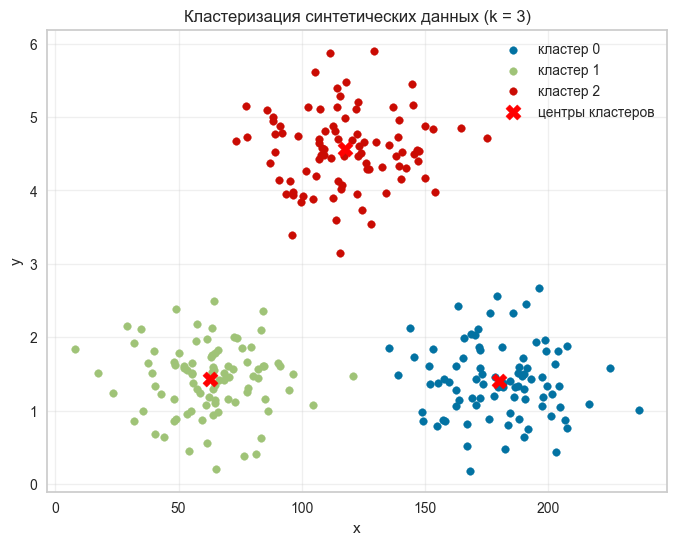

In [163]:
# стандартизация признаков x и y
scaler = StandardScaler()
X_scaled = scaler.fit_transform(synthetic_df[["x", "y"]])

# обучение модели k-means для трёх кластеров и получение меток с помощью fit_predict
km3 = KMeans(n_clusters=3, random_state=seed, n_init=10)
labels3 = km3.fit_predict(X_scaled)

# расчёт коэффициента силуэта для оценки качества кластеризации
sil3 = silhouette_score(X_scaled, labels3)
print("коэффициент силуэта (k = 3):", sil3)

# обратное преобразование центров кластеров в исходный масштаб признаков
centers3 = scaler.inverse_transform(km3.cluster_centers_)

# визуализация кластеров и центров на плоскости
plt.figure(figsize=(8, 6))

for lab in np.unique(labels3):
    plt.scatter(
        synthetic_df["x"].values[labels3 == lab],
        synthetic_df["y"].values[labels3 == lab],
        s=30,
        label=f"кластер {lab}",
    )

plt.scatter(
    centers3[:, 0],
    centers3[:, 1],
    color="red",
    s=120,
    marker="X",
    label="центры кластеров",
)

plt.title("Кластеризация синтетических данных (k = 3)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 1.3 Кластеризация при k = 2 и k = 4

Далее параметры модели k‑means изменяются таким образом, чтобы получить разбиение на два и четыре кластера.

На каждом шаге выполняются те же действия, что и при `k = 3`: используется уже стандартизованный набор признаков, обучается модель `KMeans` с заданным числом кластеров, с помощью метода `fit_predict` получаются метки кластеров, вычисляется коэффициент силуэта и строится диаграмма рассеяния с визуализацией кластеров и центров (в исходном масштабе признаков). Результаты для `k = 2` и `k = 4` затем будут сравнены с разбиением при `k = 3`.


коэффициент силуэта (k = 2): 0.4912381467062004
коэффициент силуэта (k = 4): 0.5850916821336953


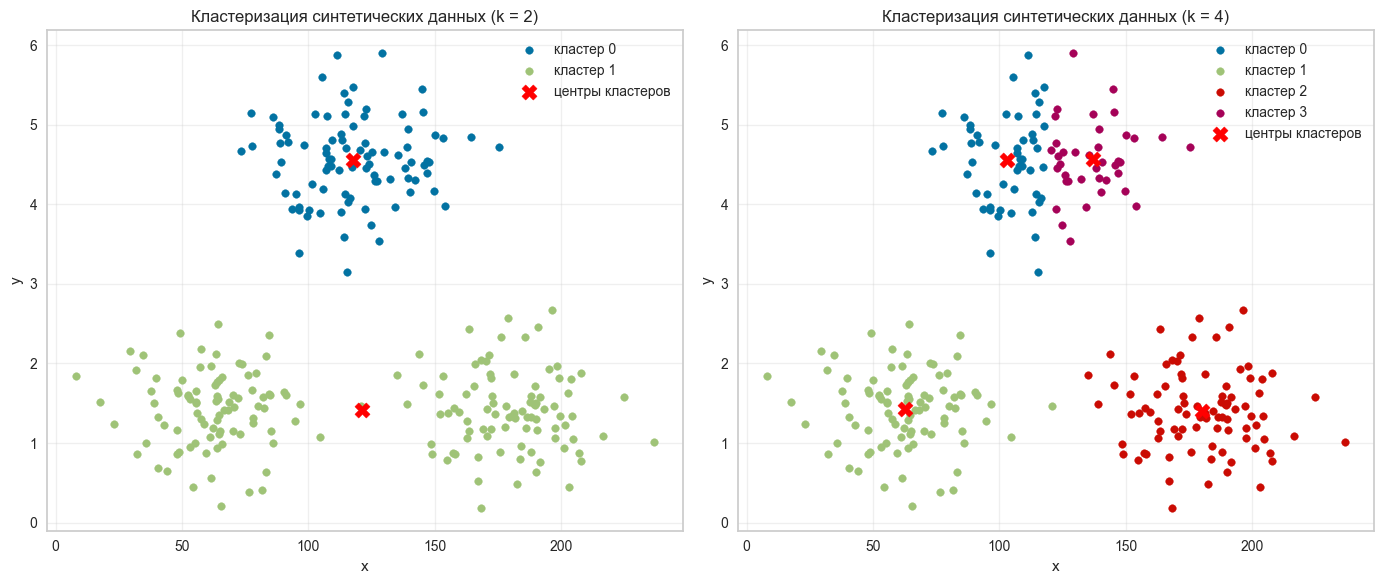

In [164]:
# кластеризация для k = 2 и k = 4 на тех же стандартизованных признаках

# k = 2
km2 = KMeans(n_clusters=2, random_state=seed, n_init=10)
labels2 = km2.fit_predict(X_scaled)

sil2 = silhouette_score(X_scaled, labels2)
print("коэффициент силуэта (k = 2):", sil2)

centers2 = scaler.inverse_transform(km2.cluster_centers_)

# k = 4
km4 = KMeans(n_clusters=4, random_state=seed, n_init=10)
labels4 = km4.fit_predict(X_scaled)

sil4 = silhouette_score(X_scaled, labels4)
print("коэффициент силуэта (k = 4):", sil4)

centers4 = scaler.inverse_transform(km4.cluster_centers_)

# визуализация результатов для k = 2 и k = 4
plt.figure(figsize=(14, 6))

# график для k = 2
plt.subplot(1, 2, 1)
for lab in np.unique(labels2):
    plt.scatter(
        synthetic_df["x"].values[labels2 == lab],
        synthetic_df["y"].values[labels2 == lab],
        s=30,
        label=f"кластер {lab}",
    )
plt.scatter(
    centers2[:, 0],
    centers2[:, 1],
    color="red",
    s=120,
    marker="X",
    label="центры кластеров",
)
plt.title("Кластеризация синтетических данных (k = 2)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)

# график для k = 4
plt.subplot(1, 2, 2)
for lab in np.unique(labels4):
    plt.scatter(
        synthetic_df["x"].values[labels4 == lab],
        synthetic_df["y"].values[labels4 == lab],
        s=30,
        label=f"кластер {lab}",
    )
plt.scatter(
    centers4[:, 0],
    centers4[:, 1],
    color="red",
    s=120,
    marker="X",
    label="центры кластеров",
)
plt.title("Кластеризация синтетических данных (k = 4)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 1.4 Сравнение кластеризаций для k = 2, 3 и 4

При разбиении на два кластера (`k = 2`) коэффициент силуэта составляет примерно 0.49, и на графике видно, что два нижних облака точек объединяются в один кластер. Такое разбиение слишком грубо: в одном кластере оказываются объекты с заметно различным положением по оси `x`, а геометрия групп становится менее чёткой.

Для `k = 3` коэффициент силуэта около 0.71, что существенно выше, чем для других значений `k`. На соответствующем графике каждый из трёх визуально различимых облаков точек образует свой кластер, а центры кластеров располагаются в геометрических центрах этих групп. Кластеры получаются компактными и хорошо отделёнными друг от друга.

При `k = 4` коэффициент силуэта снижается до примерно 0.59: верхний кластер фактически "разрезается" на две части, тогда как его точки всё ещё образуют одну естественную группу. В результате модель начинает дробить одну из плотных групп без явной необходимости.

Таким образом, по значениям коэффициента силуэта и по расположению точек на графиках оптимальным выбором для данного синтетического набора данных является число кластеров `k = 3` - оно соответствует естественной структуре данных и обеспечивает наилучшее качество кластеризации.


## 1.5 Построение графика по методу локтя

На этом шаге используется метод локтя для подбора оптимального числа кластеров. Идея метода заключается в том, чтобы проследить, как меняется значение внутренней метрики (например, суммарной квадратичной ошибки внутри кластеров) при увеличении `k` и найти такую точку, после которой дальнейшее увеличение числа кластеров даёт всё меньший выигрыш по метрике.

Для построения графика будет использован визуализатор `KElbowVisualizer` из библиотеки `yellowbrick`: он обучает модель k‑means для нескольких значений `k`, рассчитывает показатель "distortion" и строит график зависимости этой метрики от числа кластеров. По характерному перелому "локтю" на этом графике можно сделать вывод об оптимальном количестве кластеров для рассматриваемого набора данных.


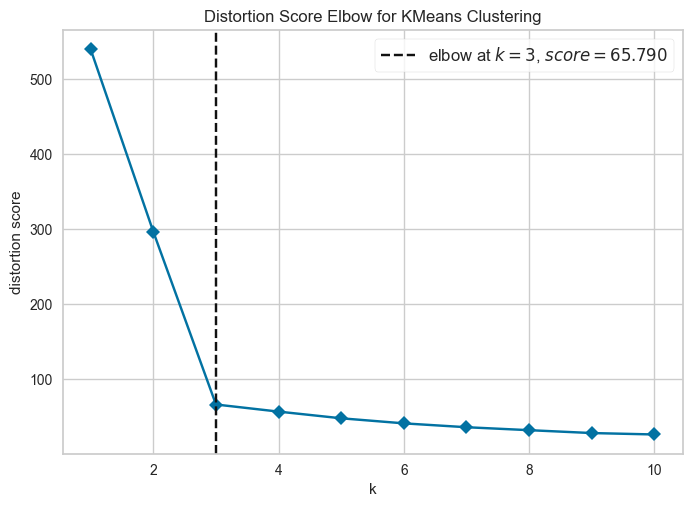

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [165]:
# построение графика по методу локтя с помощью KElbowVisualizer
from yellowbrick.cluster import KElbowVisualizer

# базовая модель k-means без указания числа кластеров
km_base = KMeans(random_state=seed, n_init=10)

visualizer = KElbowVisualizer(km_base, k=(1, 11), timings=False)
visualizer.fit(X_scaled)
visualizer.show()


## 1.6 Выводы по части 1

По значению коэффициента силуэта наилучшее качество кластеризации достигается при k = 3: при таком числе кластеров силуэтный коэффициент максимален и значительно выше, чем для k = 2 и k = 4. Визуально это соответствует тому, что каждая из трех естественных групп точек на плоскости формирует отдельный компактный кластер, хорошо отделенный от остальных.

График по методу локтя также показывает перелом кривой примерно при k = 3: после этого значения уменьшение показателя distortion при увеличении числа кластеров становится заметно менее выраженным. Таким образом, оба подхода (силуэт и метод локтя) согласованно указывают на то, что оптимальным количеством кластеров для синтетического набора данных является k = 3.


# 2. Часть 2. Кластеризация реального набора данных employee_attrition

Во второй части работы выполняется кластеризация реального набора данных employee_attrition, содержащего информацию о сотрудниках компании и признаке Attrition (уволился сотрудник или остался).

Цель части заключается в том, чтобы, не используя целевую переменную при обучении моделей кластеризации, выделить группы сотрудников с разными профилями, сопоставить полученные кластеры с признаком Attrition и оценить, насколько хорошо выделенные группы соотносятся с фактом увольнения.


## 2.1 Загрузка и первичный анализ набора данных

На этом шаге загружается набор данных employee_attrition из папки datasets, выполняется первичный осмотр структуры датафрейма и базовая описательная статистика по числовым признакам. Дополнительно выводятся несколько первых строк таблицы и распределение по ключевым категориальным столбцам, чтобы оценить состав выборки и понять, какие признаки будут использоваться на следующих этапах предобработки и кластеризации.


In [166]:
# загрузка датасета employee_attrition и первичный осмотр
emp_df = pd.read_csv("datasets/employee_attrition.csv")

print("размер датасета:", emp_df.shape)
print()

print("первые строки датафрейма:")
print(emp_df.head())
print()

print("информация о столбцах:")
print(emp_df.info())
print()

print("описательная статистика по числовым признакам:")
print(emp_df.describe())
print()

print("распределение по департаментам:")
print(emp_df["department"].value_counts())
print()

print("распределение по целевой переменной Attrition:")
print(emp_df["Attrition"].value_counts())


размер датасета: (3048, 12)

первые строки датафрейма:
   age gender   department  job_level marital_status  monthly_income  \
0   31      F  Engineering          1         Single          5163.0   
1   29      M        Sales          2       Divorced         13878.0   
2   26      F      Support          1        Married          4712.0   
3   61      F  Engineering          2         Single         12196.0   
4   59      F        Sales          5         Single         15823.0   

   years_at_company overtime  performance_rating  distance_from_home_km  \
0                14       No                   3                   24.1   
1                 1       No                   3                    4.6   
2                 6       No                   3                    8.4   
3                12      Yes                   4                    2.2   
4                18       No                   4                    7.2   

   training_hours_last_year  Attrition  
0                   

## 2.2 Предварительная обработка и краткие выводы по структуре данных

По результатам первичного анализа датасет employee_attrition содержит 3048 записей и 12 столбцов, среди которых 8 числовых признаков и 4 категориальных. Пропусков в данных не обнаружено, что позволяет сразу переходить к этапам масштабирования и кодирования признаков без дополнительного заполнения или удаления строк.

Распределение по департаментам неоднородно: наибольшее число сотрудников работает в Engineering и Sales, тогда как HR и Finance представлены меньшими группами. Целевая переменная Attrition сильно несбалансирована (около 9 % увольнений), то есть большинство сотрудников в выборке остаются в компании; эта особенность будет учитываться при интерпретации полученных кластеров.

Числовые признаки (возраст, уровень должности, стаж в компании, доход, расстояние до офиса, часы обучения и оценка эффективности) имеют разумные диапазоны значений и не содержат явно аномальных экстремумов, поэтому в дальнейшем для них достаточно стандартизации без дополнительной очистки от выбросов.


## 2.3 Выделение целевой переменной и матрица диаграмм рассеяния

Далее в качестве целевой переменной для анализа выбирается столбец Attrition, который отражает факт увольнения сотрудника (1 - сотрудник уволился, 0 - остался). Эта переменная исключается из признакового пространства, так как методы кластеризации относятся к обучению без учителя и не должны использовать информацию о целевом классе при построении кластеров.

Для числовых признаков строится матрица диаграмм рассеяния (pairplot), в которой точки дополнительно раскрашиваются по значению Attrition. Это позволяет визуально оценить, как распределяются уволившиеся и оставшиеся сотрудники в пространстве исходных признаков и есть ли заметные разделяющие границы, которые потенциально могут быть учтены при последующей кластеризации.


числовые признаки: ['age', 'job_level', 'monthly_income', 'years_at_company', 'performance_rating', 'distance_from_home_km', 'training_hours_last_year']
категориальные признаки: ['gender', 'department', 'marital_status', 'overtime']


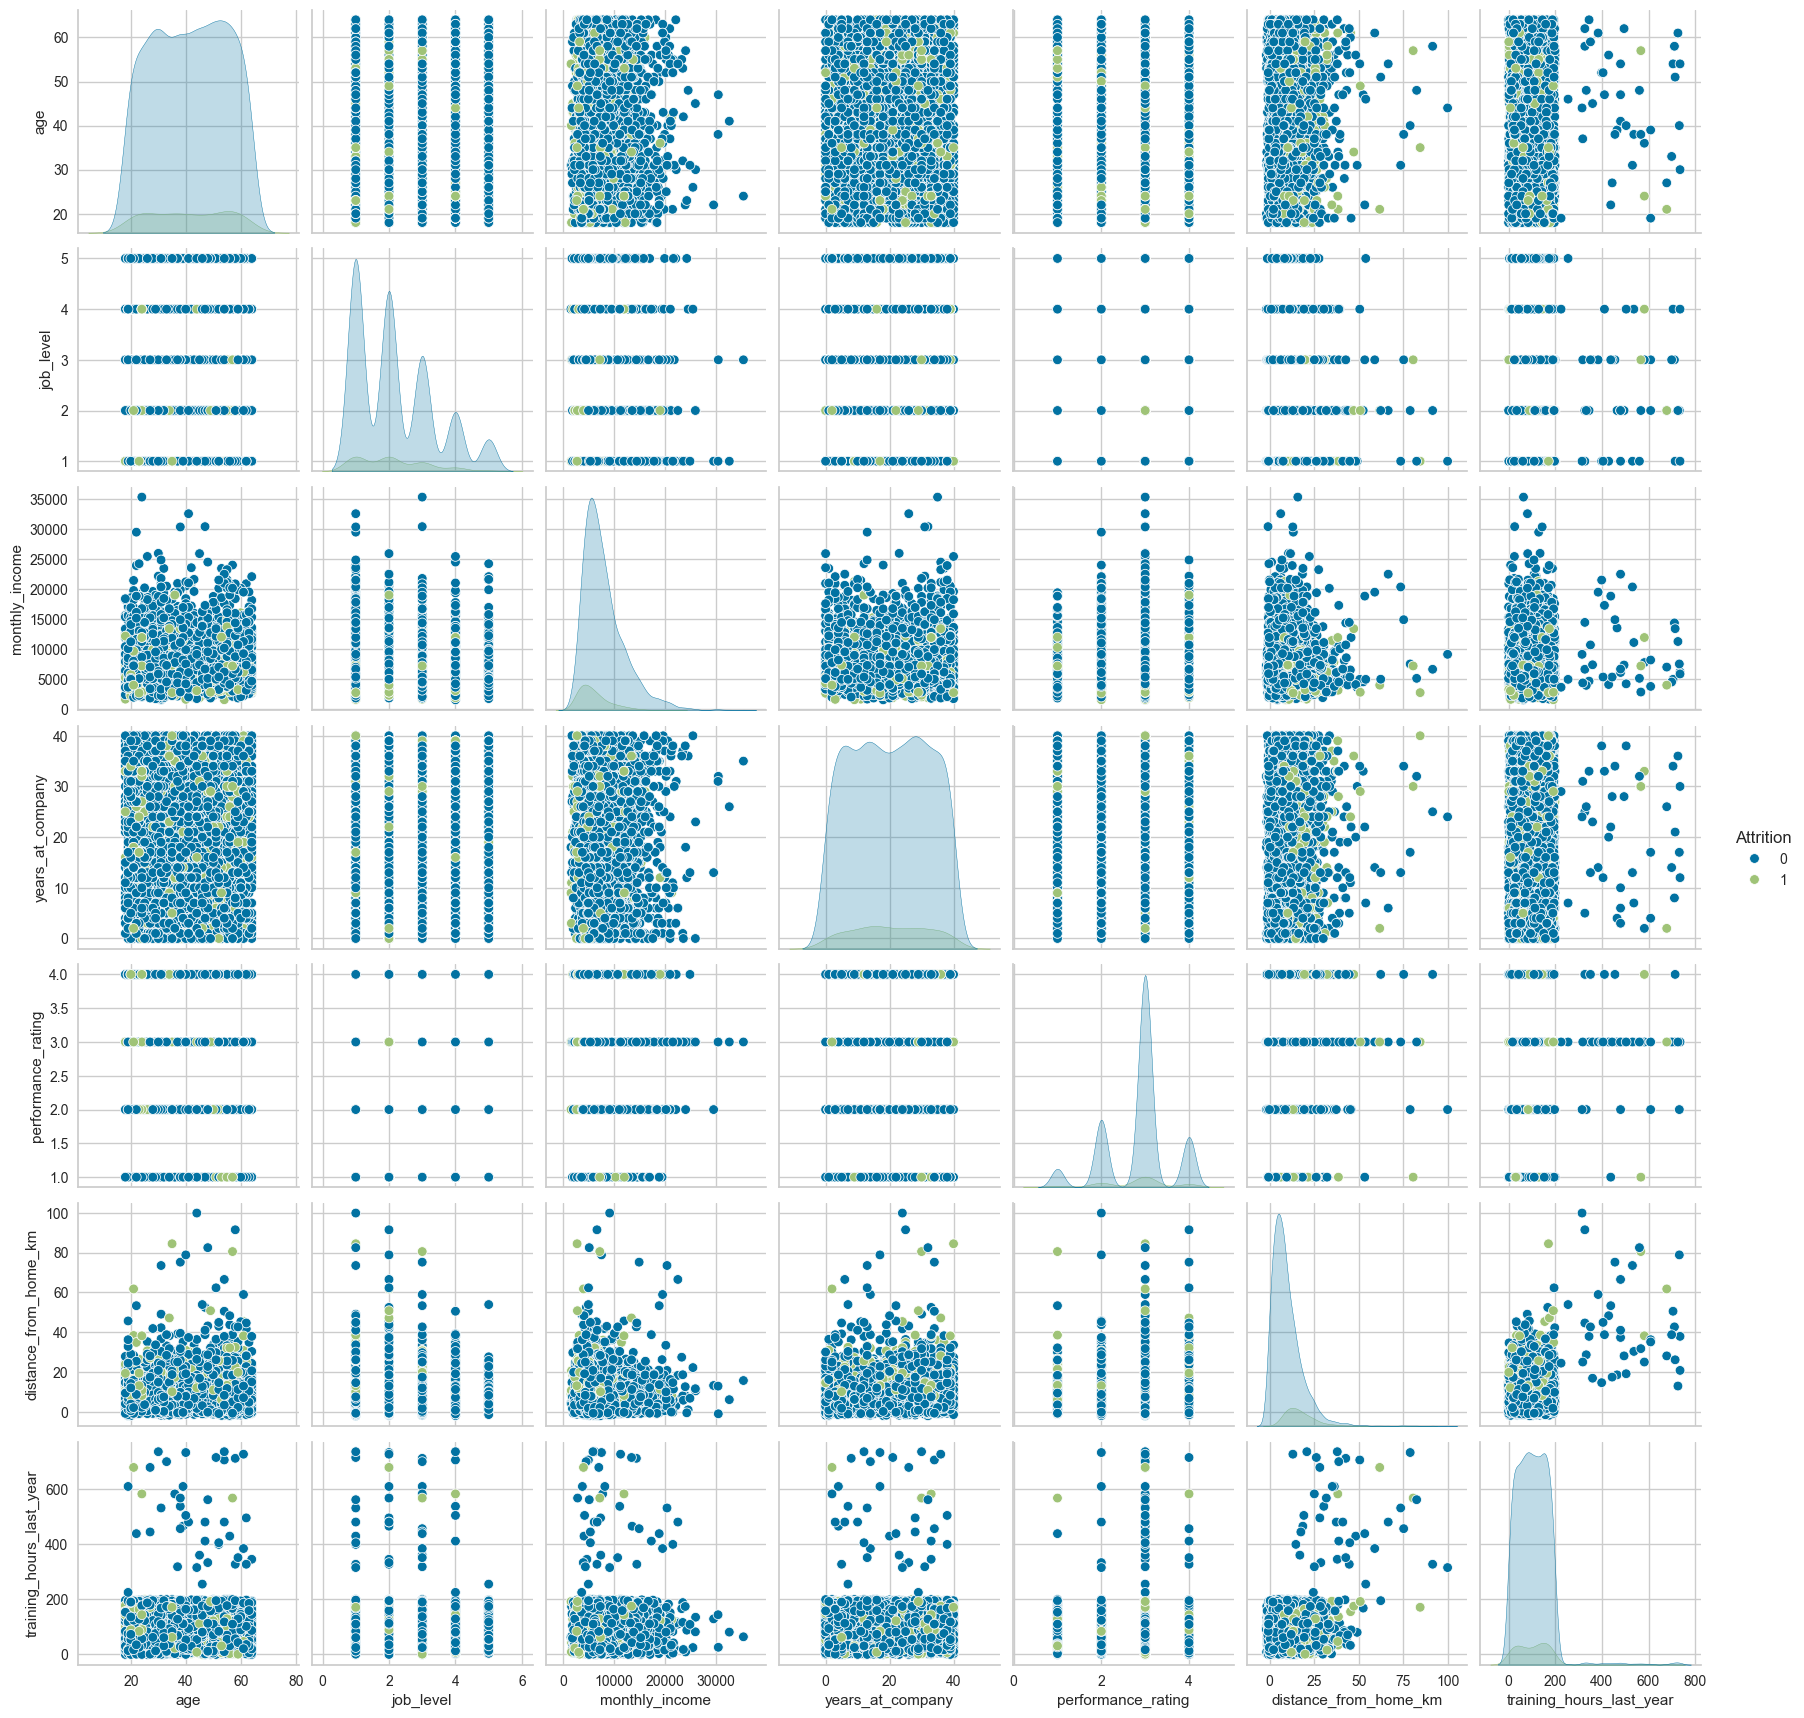

In [167]:
# выделение целевой переменной Attrition и построение матрицы диаграмм рассеяния
import seaborn as sns

# целевая переменная - Attrition (будет использоваться только для интерпретации кластеров)
target_col = "Attrition"
y = emp_df[target_col].copy()
X = emp_df.drop(columns=[target_col]).copy()

# списки числовых и категориальных признаков
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("числовые признаки:", num_cols)
print("категориальные признаки:", cat_cols)

# матрица диаграмм рассеяния для числовых признаков с раскраской по Attrition
sns.pairplot(emp_df, vars=num_cols, hue=target_col)
plt.show()


## 2.4 Выводы по матрице диаграмм рассеяния

По матрице диаграмм рассеяния видно, что объекты с Attrition = 1 встречаются существенно реже, чем с Attrition = 0, и в большинстве проекций сильно перекрываются с основной массой точек. Однако можно заметить, что уволившиеся сотрудники чаще встречаются среди работников с меньшим стажем в компании и более низким уровнем дохода и грейда должности: в областях больших значений years_at_company, job_level и monthly_income точек с Attrition = 1 заметно меньше.

Для таких признаков, как age, performance_rating и training_hours_last_year, разделяющие границы по факту увольнения выражены значительно слабее: уволившиеся и оставшиеся сотрудники распределены по этим осям схожим образом. В целом матрица рассеяния показывает, что линейно разделить два класса по исходным числовым признакам сложно, что мотивирует использование кластеризации и последующего анализа полученных групп.

## 2.5 Стандартизация числовых данных и кодирование категориальных признаков

На следующем шаге выполняется подготовка признаков для дальнейшей кластеризации: числовые столбцы масштабируются с помощью StandardScaler, а категориальные признаки переводятся в числовой формат с помощью one-hot кодирования.

В результате формируется матрица признаков X_final, в которой все признаки приведены к сопоставимому масштабу и готовы для обучения моделей кластеризации. Целевая переменная Attrition при этом не включается в X_final и будет использоваться только для последующей интерпретации полученных кластеров и расчета внешних метрик качества.


In [168]:
# стандартизация числовых признаков и one-hot кодирование категориальных столбцов

num_scaler = StandardScaler()

# стандартизация числовых признаков
X_num_scaled = num_scaler.fit_transform(emp_df[num_cols])
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=num_cols)

# one-hot кодирование категориальных признаков
X_cat_encoded = pd.get_dummies(emp_df[cat_cols], prefix=cat_cols)

# объединение числовых и категориальных признаков в единый датафрейм
X_final = pd.concat([X_num_scaled_df, X_cat_encoded], axis=1)

print("размер итоговой матрицы признаков:", X_final.shape)
X_final.head()


размер итоговой матрицы признаков: (3048, 19)


,age,job_level,monthly_income,years_at_company,performance_rating,distance_from_home_km,training_hours_last_year,gender_F,gender_M,department_Engineering,department_Finance,department_HR,department_Sales,department_Support,marital_status_Divorced,marital_status_Married,marital_status_Single,overtime_No,overtime_Yes
0,-0.767569,-1.020047,-0.632023,-0.516075,0.220018,1.505762,0.471737,True,False,True,False,False,False,False,False,False,True,True,False
1,-0.916495,-0.162127,1.515497,-1.615482,0.220018,-0.612198,0.471737,False,True,False,False,False,True,False,True,False,False,True,False
2,-1.139883,-1.020047,-0.743157,-1.192633,0.220018,-0.199467,0.563286,True,False,False,False,False,False,True,False,True,False,True,False
3,1.466318,-0.162127,1.101025,-0.685215,1.583058,-0.872870,-0.090635,True,False,True,False,False,False,False,False,False,True,False,True
4,1.317392,2.411635,1.994778,-0.177796,1.583058,-0.329803,-1.241536,True,False,False,False,False,True,False,False,False,True,True,False


## 2.6 Кластеризация объектов методом k-means и подбор числа кластеров

На этом шаге выполняется кластеризация сотрудников по матрице признаков X_final с помощью алгоритма k-means. Сначала подбирается подходящее число кластеров k по методу локтя: для ряда значений k строится график зависимости distortion score от количества кластеров, и по характерному перелому определяется диапазон разумных значений k.

После анализа графика будет выбрано конкретное значение k, на котором обучится финальная модель k-means; далее для получившихся кластеров будут рассчитаны размеры групп и средние значения признаков, а также внутренние и внешние метрики качества кластеризации.


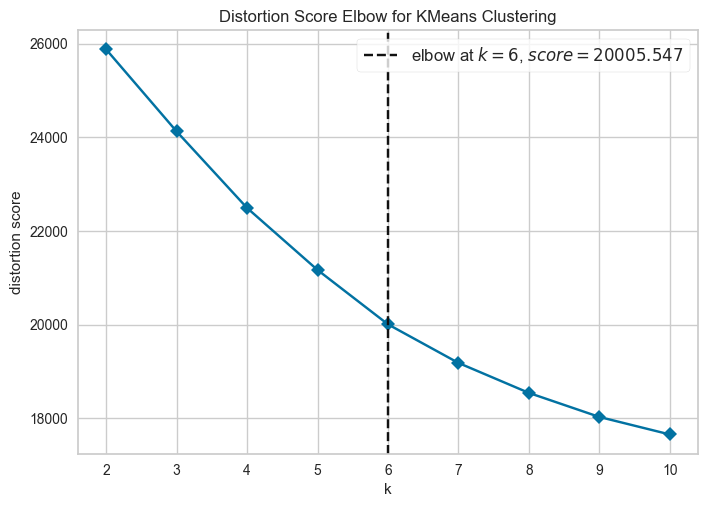

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [169]:
# подбор числа кластеров по методу локтя для матрицы X_final

km_emp = KMeans(random_state=42, n_init=10)

visualizer_emp = KElbowVisualizer(km_emp, k=(2, 11), timings=False)
visualizer_emp.fit(X_final)
visualizer_emp.show()


## 2.7 Обучение модели k-means при k = 6 и анализ кластеров

По графику метода локтя для матрицы X_final точка перегиба приходится примерно на k = 6, поэтому в дальнейшем для k-means используется именно это значение числа кластеров. На данном шаге выполняется обучение модели k-means при k = 6, к исходному датафрейму добавляется столбец с номерами кластеров, после чего рассчитываются размеры групп и средние значения признаков внутри каждого кластера.

Эти агрегированные характеристики позволяют описать типичный профиль сотрудника в каждом кластере и сопоставить полученные группы с целевой переменной Attrition.


In [170]:
# обучение k-means при k = 6 и анализ полученных кластеров

k = 6
n_init = 10

kmeans_emp = KMeans(n_clusters=k, random_state=seed, n_init=n_init)
cluster_labels_kmeans = kmeans_emp.fit_predict(X_final)

# добавляем метки кластеров в исходный датафрейм
emp_with_clusters = emp_df.copy()
emp_with_clusters["cluster_kmeans"] = cluster_labels_kmeans

# средние значения признаков по каждому кластеру
cluster_means_kmeans = emp_with_clusters.groupby("cluster_kmeans").mean(numeric_only=True)

print(f"средние значения числовых признаков по {k} кластерам (k-means):")
print(cluster_means_kmeans)
print()

print("размер кластеров (число сотрудников в каждой группе):")
print(emp_with_clusters["cluster_kmeans"].value_counts())


средние значения числовых признаков по 6 кластерам (k-means):
                      age  job_level  monthly_income  years_at_company  \
cluster_kmeans                                                           
0               41.653846   3.973776     7068.512238         18.760490   
1               54.110828   1.671338     6521.755414         22.001274   
2               28.609179   1.650904     6552.517385         19.730181   
3               41.127841   1.968750    15762.372159         19.872159   
4               43.723404   2.382979     8522.234043         20.553191   
5               39.270506   1.910995     6512.359511         19.411867   

                performance_rating  distance_from_home_km  \
cluster_kmeans                                              
0                         3.001748               9.238636   
1                         3.136306              10.728280   
2                         3.221140               9.173018   
3                         2.923295      

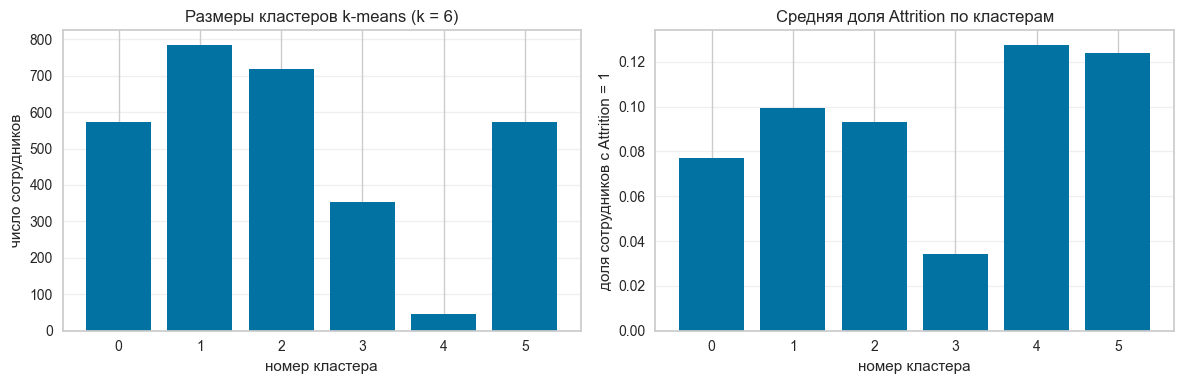

In [171]:
# визуализация размеров кластеров и доли увольнений в каждом кластере

# количества сотрудников по кластерам (для наглядности сортируем по номеру кластера)
cluster_sizes = emp_with_clusters["cluster_kmeans"].value_counts().sort_index()

# средняя доля Attrition по кластерам (уже содержится в cluster_means_kmeans)
attrition_rates = cluster_means_kmeans["Attrition"].sort_index()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(cluster_sizes.index, cluster_sizes.values)
plt.title("Размеры кластеров k-means (k = 6)")
plt.xlabel("номер кластера")
plt.ylabel("число сотрудников")
plt.grid(axis="y", alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(attrition_rates.index, attrition_rates.values)
plt.title("Средняя доля Attrition по кластерам")
plt.xlabel("номер кластера")
plt.ylabel("доля сотрудников с Attrition = 1")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 2.8 Выводы по кластерам k-means (k = 6)

Полученные кластеры заметно различаются по возрасту сотрудников, уровню должности, доходу, стажу и связанным с ними показателям.

Кластер 0: сотрудники среднего возраста (около 42 лет) с высоким грейдом должности (в среднем почти 4) и умеренным доходом. Стаж в компании около 19 лет, оценка эффективности близка к 3, показатель Attrition ниже среднего (около 7,7 %). Это опытные специалисты на относительно высоких позициях, которые, как правило, остаются в компании.

Кластер 1: самая возрастная группа (средний возраст более 54 лет) с невысоким грейдом (1,7) и умеренным доходом. Стаж также относительно большой (около 22 лет), а вероятность увольнения немного выше, чем в кластере 0 (около 9,9 %). Кластер можно интерпретировать как старших по возрасту сотрудников на базовых позициях с долгим стажем.

Кластер 2: самая молодая группа (средний возраст около 29 лет) с невысоким грейдом и сопоставимым с кластером 1 доходом, при этом стаж в компании также довольно велик (около 20 лет). Оценка эффективности чуть выше 3, а Attrition близок к среднему уровню (около 9,3 %). Это молодые сотрудники, давно работающие в компании, без резких отличий по риску увольнения.

Кластер 3: сотрудники среднего возраста с самым высоким доходом (свыше 15 000) при среднем грейде около 2. Это небольшая по размеру, но наиболее благополучная группа: у них относительно высокий доход, высокая оценка эффективности и самый низкий уровень Attrition (около 3,4 %). Кластер можно рассматривать как ядро лояльных и финансово успешных сотрудников.

Кластер 4: небольшая группа (менее 50 человек) с заметно большим расстоянием от дома до офиса (в среднем около 46 км) и крайне высоким числом часов обучения за последний год (среднее значение значительно превышает другие кластеры). Уровень Attrition здесь самый высокий (около 12,8 %), что позволяет интерпретировать этот кластер как группу сотрудников с высокой обучаемостью и удаленностью от офиса, среди которых чаще происходят увольнения.

Кластер 5: сотрудники немного моложе среднего с невысоким грейдом и доходом, при этом с самой низкой оценкой эффективности (среднее значение performance_rating существенно ниже 3). Уровень Attrition здесь также повышен (около 12,4 %). Кластер описывает работников с менее высокой результативностью и повышенным риском увольнения.


## 2.9 Метрики качества кластеризации k-means

Для оценки качества кластеризации k-means на матрице X_final будут рассчитаны как внутренняя метрика (коэффициент силуэта), так и несколько внешних метрик, сравнивающих найденные кластеры с истинными значениями Attrition: Adjusted Rand Index (ARI), Adjusted Mutual Information (AMI), а также homogeneity, completeness и V-measure.

Внутренняя метрика показывает, насколько хорошо объекты внутри кластера похожи друг на друга по признакам и насколько далеко они находятся от центров других кластеров. Внешние метрики позволяют оценить, насколько структура кластеров соотносится с делением сотрудников на уволившихся и оставшихся.


In [172]:
# расчет внутренних и внешних метрик качества для k-means на X_final
from sklearn.metrics import (
    adjusted_rand_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    adjusted_mutual_info_score,
)

# внутренняя метрика (силуэт на X_final)
silhouette_kmeans = silhouette_score(X_final, cluster_labels_kmeans)
print(f"k-means | коэффициент силуэта: {silhouette_kmeans:.4f}")

# внешние метрики (сравнение кластеров с Attrition)
ari_kmeans = adjusted_rand_score(y, cluster_labels_kmeans)
ami_kmeans = adjusted_mutual_info_score(y, cluster_labels_kmeans)
homo_kmeans = homogeneity_score(y, cluster_labels_kmeans)
comp_kmeans = completeness_score(y, cluster_labels_kmeans)
v_kmeans = v_measure_score(y, cluster_labels_kmeans)

print(f"k-means | ARI: {ari_kmeans:.4f}")
print(f"k-means | AMI: {ami_kmeans:.4f}")
print(f"k-means | homogeneity: {homo_kmeans:.4f}")
print(f"k-means | completeness: {comp_kmeans:.4f}")
print(f"k-means | V-measure: {v_kmeans:.4f}")


k-means | коэффициент силуэта: 0.0913
k-means | ARI: -0.0022
k-means | AMI: 0.0038
k-means | homogeneity: 0.0147
k-means | completeness: 0.0027
k-means | V-measure: 0.0046


## 2.10 Выводы по метрикам k-means

Коэффициент силуэта для кластеризации k-means на матрице X_final составляет около 0.09, что близко к нулю и указывает на слабую геометрическую разделимость кластеров: многие объекты находятся примерно на одинаковом расстоянии от центров своего и соседних кластеров, а сами группы заметно перекрываются в признаковом пространстве.

Внешние метрики (ARI ≈ -0.002, AMI ≈ 0.004, homogeneity ≈ 0.015, completeness ≈ 0.003, V-measure ≈ 0.005) также находятся очень близко к нулю. Это значит, что найденное разбиение практически не коррелирует с истинной целевой переменной Attrition: уволившиеся и оставшиеся сотрудники распределены по кластерам почти случайным образом, и ни один из кластеров не соответствует однородной группе только из ушедших или только из оставшихся сотрудников.

Таким образом, с точки зрения предсказания факта увольнения кластеризация k-means на полном наборе признаков X_final не даёт качественного разделения классов и скорее подходит для описательного сегментирования сотрудников по профилю признаков, чем для выделения информативных групп, хорошо совпадающих с целевым признаком Attrition.


## 2.11 Кластеризация иерархическим агломеративным методом

На заключительном этапе проводится кластеризация сотрудников с использованием иерархического агломеративного метода. В отличие от k-means, этот метод последовательно объединяет объекты в кластеры, формируя иерархию разбиений, которую удобно визуализировать с помощью дендрограммы.

Сначала по матрице признаков X_final будет построена дендрограмма (метод "ward"), по которой визуально оценивается разумное количество кластеров. Затем для выбранного числа кластеров выполняется агломеративная кластеризация, рассчитываются средние значения признаков и размеры кластеров, а также метрики качества по аналогии с методом k-means.


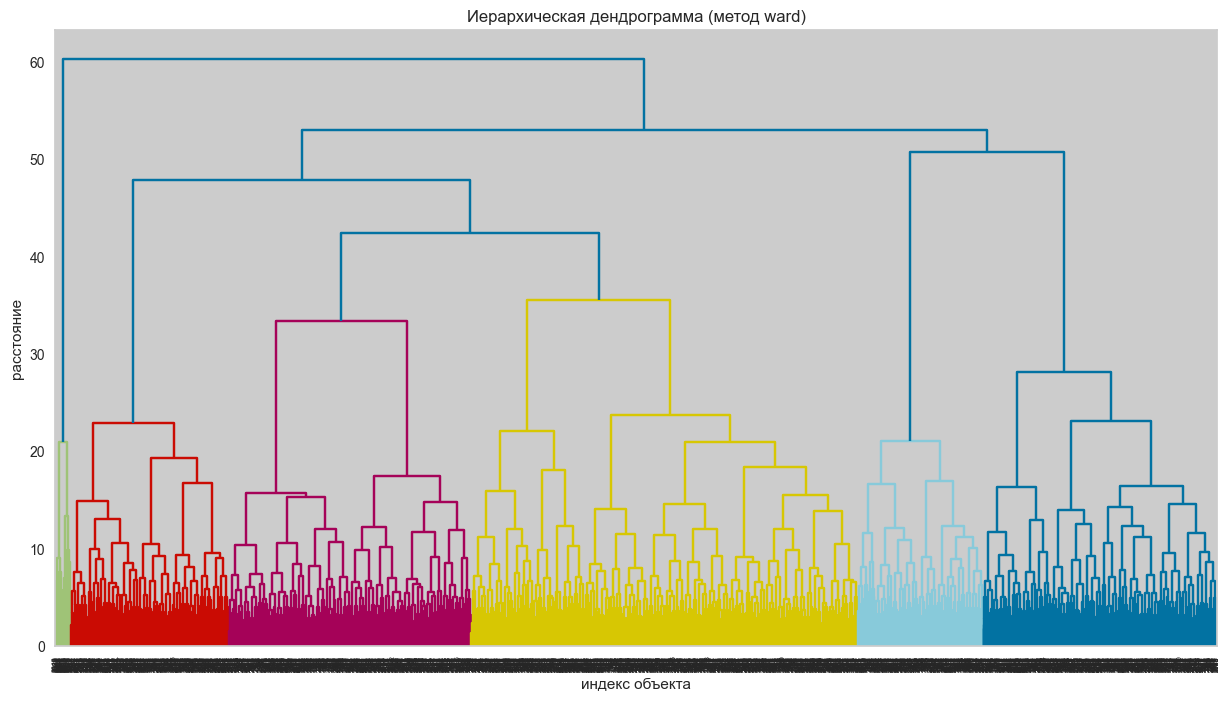

In [173]:
# построение дендрограммы для X_final
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(X_final, method="ward")

plt.figure(figsize=(15, 8))
plt.title("Иерархическая дендрограмма (метод ward)")
plt.xlabel("индекс объекта")
plt.ylabel("расстояние")

dendrogram(linkage_matrix, orientation="top")
plt.show()


## 2.12 Агломеративная кластеризация с фиксированным числом кластеров

По дендрограмме можно выделить несколько крупных ветвей, что соответствует разбиению данных на несколько крупных групп. Для дальнейшего анализа в работе фиксируется число кластеров k = 4: это значение позволяет получить относительно компактные и интерпретируемые группы, не дробя данные на слишком большое количество мелких кластеров.

На этом шаге выполняется агломеративная кластеризация с методом связывания "ward" и числом кластеров k = 4, к датафрейму добавляются метки кластеров, а также рассчитываются размеры групп и средние значения числовых признаков, включая Attrition, внутри каждого кластера.


In [174]:
# агломеративная кластеризация при k = 4
from sklearn.cluster import AgglomerativeClustering

k_agg = 4

agg_cluster = AgglomerativeClustering(n_clusters=k_agg, linkage="ward")
cluster_labels_agg = agg_cluster.fit_predict(X_final)

# добавляем метки агломеративных кластеров в датафрейм
emp_with_clusters["cluster_agg"] = cluster_labels_agg

# средние значения числовых признаков по каждому агломеративному кластеру
cluster_means_agg = emp_with_clusters.groupby("cluster_agg").mean(numeric_only=True)

print(f"средние значения числовых признаков по {k_agg} кластерам (агломеративный метод):")
print(cluster_means_agg)
print()

print("размер кластеров (число сотрудников в каждой группе, агломеративный метод):")
print(emp_with_clusters["cluster_agg"].value_counts())


средние значения числовых признаков по 4 кластерам (агломеративный метод):
                   age  job_level  monthly_income  years_at_company  \
cluster_agg                                                           
0            41.439166   1.818226     6515.367911         20.781386   
1            41.094225   1.759878    15134.802432         20.188450   
2            40.771615   3.654160     7763.828711         17.769984   
3            44.302326   2.372093     8714.604651         20.116279   

             performance_rating  distance_from_home_km  \
cluster_agg                                              
0                      2.743093              10.373921   
1                      3.024316               8.382736   
2                      3.048940               8.194780   
3                      3.000000              46.932558   

             training_hours_last_year  Attrition  cluster_kmeans  
cluster_agg                                                       
0              

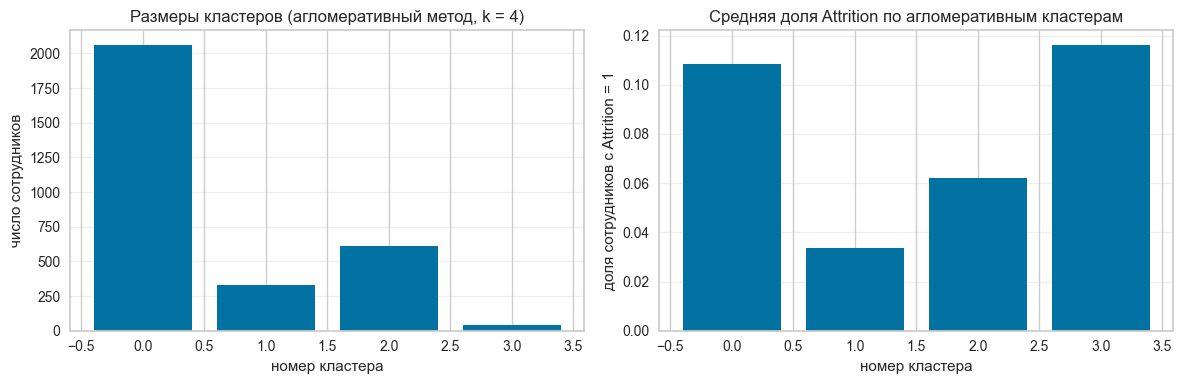

In [175]:
# визуализация размеров агломеративных кластеров и доли Attrition в них

agg_sizes = emp_with_clusters["cluster_agg"].value_counts().sort_index()
agg_attrition_rates = cluster_means_agg["Attrition"].sort_index()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(agg_sizes.index, agg_sizes.values)
plt.title("Размеры кластеров (агломеративный метод, k = 4)")
plt.xlabel("номер кластера")
plt.ylabel("число сотрудников")
plt.grid(axis="y", alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(agg_attrition_rates.index, agg_attrition_rates.values)
plt.title("Средняя доля Attrition по агломеративным кластерам")
plt.xlabel("номер кластера")
plt.ylabel("доля сотрудников с Attrition = 1")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 2.13 Метрики качества агломеративной кластеризации

Для сравнения с методом k-means для агломеративного разбиения при k = 4 также рассчитываются коэффициент силуэта и внешние метрики (ARI, AMI, homogeneity, completeness, V-measure), сравнивающие полученные кластеры с целевым признаком Attrition.

Значения этих метрик позволят оценить, даёт ли иерархический метод более чёткие и осмысленные кластеры с точки зрения как геометрического разделения, так и связи с фактом увольнения.


In [176]:
# метрики качества для агломеративной кластеризации

silhouette_agg = silhouette_score(X_final, cluster_labels_agg)
print(f"агломеративный метод | коэффициент силуэта: {silhouette_agg:.4f}")

ari_agg = adjusted_rand_score(y, cluster_labels_agg)
ami_agg = adjusted_mutual_info_score(y, cluster_labels_agg)
homo_agg = homogeneity_score(y, cluster_labels_agg)
comp_agg = completeness_score(y, cluster_labels_agg)
v_agg = v_measure_score(y, cluster_labels_agg)

print(f"агломеративный метод | ARI: {ari_agg:.4f}")
print(f"агломеративный метод | AMI: {ami_agg:.4f}")
print(f"агломеративный метод | homogeneity: {homo_agg:.4f}")
print(f"агломеративный метод | completeness: {comp_agg:.4f}")
print(f"агломеративный метод | V-measure: {v_agg:.4f}")


агломеративный метод | коэффициент силуэта: 0.0687
агломеративный метод | ARI: -0.0389
агломеративный метод | AMI: 0.0079
агломеративный метод | homogeneity: 0.0170
агломеративный метод | completeness: 0.0058
агломеративный метод | V-measure: 0.0087


## 2.14 Выводы по агломеративным кластерам (k = 4)

Агломеративная кластеризация при k = 4 дала один доминирующий кластер 0 (более 2000 сотрудников) и три существенно меньших кластера. Кластер 0 объединяет основную массу сотрудников с умеренным доходом (около 6500), базовыми грейдами и средней по выборке долей Attrition (около 10,9 %).

Кластер 1 - относительно небольшая группа (329 человек) с самым высоким доходом (свыше 15 000) и немного повышенной оценкой эффективности, при этом уровень Attrition здесь минимален (около 3,3 %). Это сотрудники с наиболее благополучным профилем и наименьшим риском увольнения.

Кластер 2 характеризуется повышенным грейдом должности (в среднем выше 3,5), умеренным доходом и несколько меньшей долей Attrition (около 6,2 %) по сравнению с кластером 0. Его можно интерпретировать как группу более квалифицированных сотрудников с умеренным риском увольнения.

Кластер 3 - очень небольшая группа (около 40 человек) с резко выделяющимися признаками: среднее расстояние до офиса почти 47 км и крайне высокое число часов обучения за последний год (свыше 490). Уровень Attrition здесь один из самых высоких (около 11,6 %), что позволяет рассматривать этот кластер как специфическую группу сотрудников с высокой нагрузкой на обучение и значительной удаленностью от офиса, среди которых чаще происходят увольнения.


# 3. Обучение с учителем для прогноза увольнений (дополнительно)

В заключение для иллюстрации того, что модели обучения с учителем лучше подходят для прогноза увольнений, чем методы кластеризации, рассматривается простая модель классификации. В качестве "учителя" выступает целевая переменная Attrition, которая задаёт для каждого сотрудника метку класса (1 - уволился, 0 - остался), а в качестве признаков используется тот же набор X_final, полученный после стандартизации числовых столбцов и кодирования категориальных переменных.

В качестве базовой модели выбрана логистическая регрессия из библиотеки scikit-learn. При подготовке работы был использован пример из документации и материалов, найденных по запросу "sklearn логистическая регрессия бинарная классификация"; логистическая регрессия часто применяется как стартовая модель для задач бинарной классификации и прогноза вероятности события (например, увольнения сотрудника). Модель обучается на обучающей выборке и оценивается на тестовой выборке по нескольким метрикам (accuracy, precision, recall, F1-score и ROC-AUC), после чего результаты сопоставляются с выводами по кластеризации.

https://habr.com/ru/companies/skillfactory/articles/701530/


In [177]:
# 3.1 Подготовка данных и разбиение на обучающую и тестовую выборки

from sklearn.model_selection import train_test_split

# признаки и целевая переменная для обучения с учителем
X_supervised = X_final.copy()
y_supervised = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_supervised,
    y_supervised,
    test_size=0.2,
    random_state=seed,
    stratify=y_supervised,
)

print("размер обучающей выборки:", X_train.shape)
print("размер тестовой выборки:", X_test.shape)


размер обучающей выборки: (2438, 19)
размер тестовой выборки: (610, 19)


In [178]:
# 3.2 Обучение простой модели логистической регрессии и оценка качества

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

# базовый классификатор - логистическая регрессия с балансировкой классов
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("accuracy:", acc)
print("precision:", prec)
print("recall:", rec)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)


accuracy: 0.7262295081967213
precision: 0.2182741116751269
recall: 0.7678571428571429
F1-score: 0.33992094861660077
ROC-AUC: 0.8270693656523982


## 3.3 Выводы по модели обучения с учителем

Полученная модель логистической регрессии обучается непосредственно на целевой переменной Attrition и на тестовой выборке даёт accuracy ≈ 0.73, recall ≈ 0.77, F1-score ≈ 0.34 и ROC-AUC ≈ 0.83. несмотря на несбалансированность классов, модель уверенно отличает уволившихся сотрудников от оставшихся и демонстрирует ненулевые, содержательные значения всех метрик, что подтверждает наличие в данных предсказуемой структуры, связанной с увольнениями.

В отличие от методов кластеризации, которые формируют группы по сходству признаков без учёта целевого класса, модель с учителем целенаправленно оптимизирует разделение между классами и потому лучше подходит для прогноза ухода сотрудников. при этом для более точного решения практической задачи можно рассматривать и другие модели (деревья решений, ансамбли, градиентный бустинг) и выполнять настройку гиперпараметров, однако даже базовая логистическая регрессия иллюстрирует принципиальное отличие подхода обучения с учителем от кластеризации и обосновывает выводы, сделанные в заключительной части работы.


# Выводы

В первой части работы на синтетическом двумерном наборе данных были рассмотрены свойства алгоритма k-means: при помощи коэффициента силуэта и метода локтя было показано, что оптимальное число кластеров соответствует реальной структуре данных (k = 3), тогда как разбиения на 2 и 4 кластера либо слишком грубо объединяют естественные группы, либо искусственно дробят их. это демонстрирует, как внутренние метрики и графические методы помогают выбирать число кластеров, соответствующее визуально наблюдаемой кластерной структуре.

Во второй части на реальном наборе employee_attrition была выполнена полная цепочка анализа: предобработка и стандартизация числовых признаков, кодирование категориальных переменных, кластеризация методом k-means с подбором числа кластеров по методу локтя, анализ профилей кластеров и их сравнение с целевым признаком Attrition. дополнительно была проведена агломеративная кластеризация с построением дендрограммы, выбором числа кластеров и расчётом метрик качества.

Расчёт коэффициента силуэта и внешних метрик (ARI, AMI, homogeneity, completeness, V-measure) показал, что и k-means, и агломеративный метод дают слабую геометрическую структуру кластеров и практически не согласуются с целевой переменной: кластеры хорошо описывают различные профили сотрудников (по возрасту, грейду, доходу, расстоянию до офиса, интенсивности обучения), но не выделяют отдельные группы "уволившихся" и "оставшихся". 

В итоге можно заключить, что для задачи прогнозирования увольнений на данном датасете целесообразнее использовать модели обучения с учителем, а методы кластеризации применять как инструмент описательного сегментирования и предварительного анализа данных, позволяющий выявлять группы сотрудников с различными характеристиками, но не заменяющий полноценную предиктивную модель.
